# Pallet Cycle Time — Gaussian Process Analysis

Models the machine-reported `cycle_time_s` (seconds) for each dispensing cycle
using a Sparse Gaussian Process fitted directly on raw event timestamps.

CSV produced by `parse_cycle_times.py` — columns: `date`, `datetime`, `cycle_time_s`.

## 1 — Imports

In [19]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.gridspec as gridspec
import GPy
from sklearn.metrics import mean_absolute_error, mean_squared_error

plt.rcParams.update({
    "figure.facecolor":  "white",
    "axes.facecolor":    "#F8F8F6",
    "axes.grid":         True,
    "grid.color":        "#E0DED6",
    "grid.linewidth":    0.6,
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "font.family":       "sans-serif",
    "axes.titlesize":    12,
    "axes.labelsize":    11,
    "xtick.labelsize":   9,
    "ytick.labelsize":   9,
})

print(f"GPy {GPy.__version__}  ready")

GPy 1.13.2  ready


## 2 — Dataset prep

In [21]:
# ── CONFIG ─────────────────────────────────────────────────────────
CSV_PATH       = "./cycle_times.csv"
SLOW_THRESHOLD = 20.0   # seconds — cycles above this are considered slow
# ───────────────────────────────────────────────────────────────────

df = pd.read_csv(CSV_PATH)
df["datetime"] = pd.to_datetime(df["datetime"], format="mixed")
df["date"]     = pd.to_datetime(df["date"]).dt.date
df = df.sort_values("datetime").reset_index(drop=True)

start = '2026-03-05 12:00'
end   = '2026-03-05 14:00'
df = df[(df['datetime'] >= start) & (df['datetime'] < end)]

print(f"Rows       : {len(df):,}")
print(f"Date range : {df['datetime'].min()}  →  {df['datetime'].max()}")
print(f"Days       : {df['date'].nunique()}")
print()
print(f"Cycle time (seconds):")
print(f"  mean  = {df['cycle_time_s'].mean():.3f}")
print(f"  std   = {df['cycle_time_s'].std():.3f}")
print(f"  min   = {df['cycle_time_s'].min():.3f}")
print(f"  p50   = {df['cycle_time_s'].quantile(0.50):.3f}")
print(f"  p95   = {df['cycle_time_s'].quantile(0.95):.3f}")
print(f"  max   = {df['cycle_time_s'].max():.3f}")
print(f"  slow  = {(df['cycle_time_s'] > SLOW_THRESHOLD).mean()*100:.1f}%  (> {SLOW_THRESHOLD}s)")

KeyError: 'datetime'

## 3 — EDA

Three views on the raw cycle time series:
- **Scatter over time** — every cycle plotted, slow threshold marked
- **Actuation rate** — cycles per hour (machine throughput over time)
- **Distribution** — shape of the cycle time spread

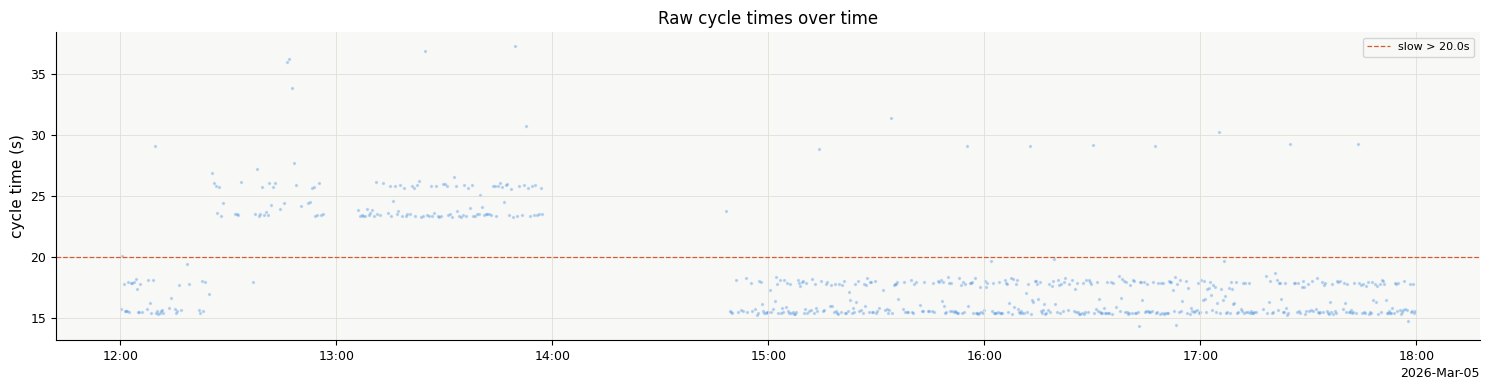

In [17]:
# ── EDA 1: Cycle time scatter over time ─────────────────────────────
fig, ax = plt.subplots(figsize=(15, 4))
ax.scatter(df["datetime"], df["cycle_time_s"],
           s=2, alpha=0.25, color="#378ADD", rasterized=True)
ax.axhline(SLOW_THRESHOLD, color="#D85A30", lw=0.9,
           linestyle="--", label=f"slow > {SLOW_THRESHOLD}s")
ax.set_title("Raw cycle times over time", fontsize=12)
ax.set_ylabel("cycle time (s)")
ax.legend(fontsize=8)
loc = mdates.AutoDateLocator()
ax.xaxis.set_major_locator(loc)
ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(loc))
plt.tight_layout()
plt.show()

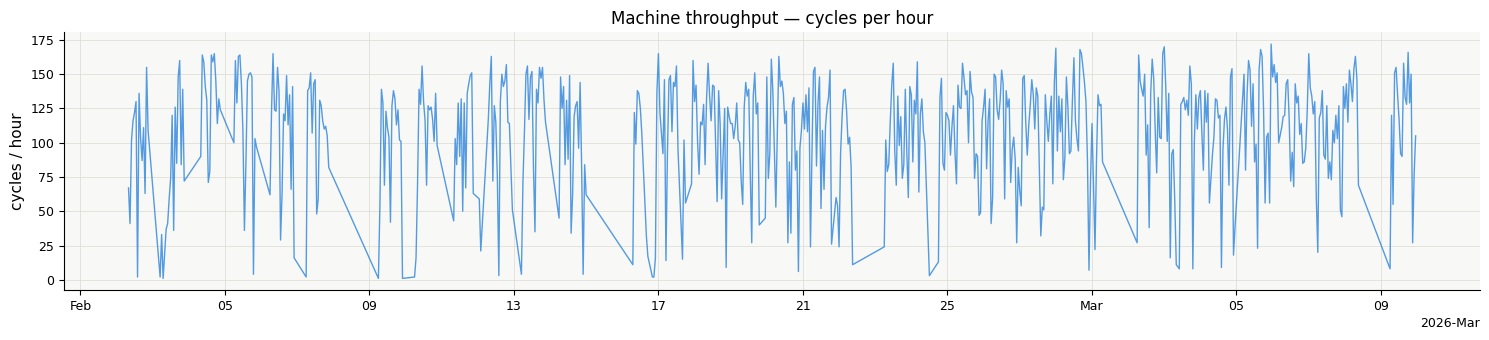

Mean throughput : 106.5 cycles/hour
Peak            : 172 cycles/hour
Min (active hrs): 1 cycles/hour


In [11]:
# ── EDA 2: Throughput — cycles per hour ─────────────────────────────
rate = df.groupby(df["datetime"].dt.floor("h")).size()

fig, ax = plt.subplots(figsize=(15, 3.5))
ax.plot(rate.index, rate.values, color="#378ADD", lw=1.0, alpha=0.85)
ax.set_title("Machine throughput — cycles per hour", fontsize=12)
ax.set_ylabel("cycles / hour")
loc = mdates.AutoDateLocator()
ax.xaxis.set_major_locator(loc)
ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(loc))
plt.tight_layout()
plt.show()

print(f"Mean throughput : {rate.mean():.1f} cycles/hour")
print(f"Peak            : {rate.max()} cycles/hour")
print(f"Min (active hrs): {rate[rate > 0].min()} cycles/hour")

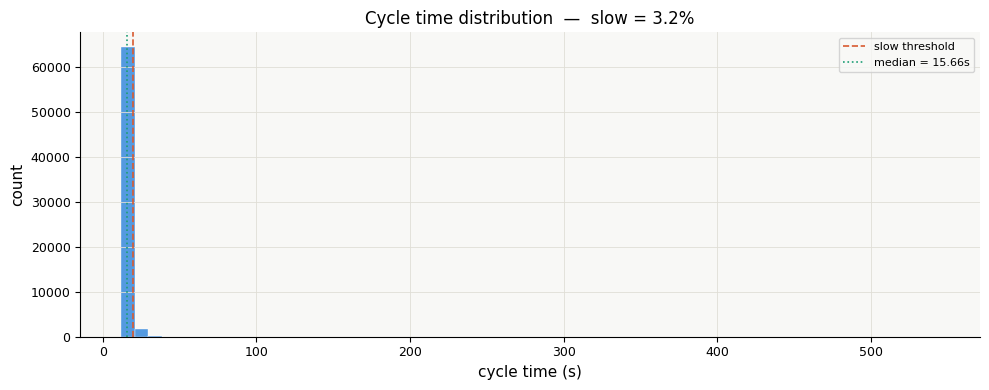

In [12]:
# ── EDA 3: Cycle time distribution ──────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(df["cycle_time_s"], bins=60,
        color="#378ADD", edgecolor="white", linewidth=0.3, alpha=0.85)
ax.axvline(SLOW_THRESHOLD,
           color="#D85A30", lw=1.2, linestyle="--", label="slow threshold")
ax.axvline(df["cycle_time_s"].median(),
           color="#1D9E75", lw=1.2, linestyle=":",
           label=f"median = {df['cycle_time_s'].median():.2f}s")
slow_pct = (df["cycle_time_s"] > SLOW_THRESHOLD).mean() * 100
ax.set_title(f"Cycle time distribution  —  slow = {slow_pct:.1f}%", fontsize=12)
ax.set_xlabel("cycle time (s)")
ax.set_ylabel("count")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## 4 — GP model

`run_gp()` fits a **Sparse Gaussian Process** directly on raw cycle timestamps.
Each cycle event is an observation `(datetime, cycle_time_s)`.

The time axis is normalised to `[0, 1]` over the training window to prevent
lengthscale collapse (see inline comments for details).

### Kernel options

| String | Behaviour | When to use |
|---|---|---|
| `"rbf"` | Very smooth | Clean, slowly-drifting signal |
| `"matern52"` | Moderately rough | **Default — good for noisy machine data** |
| `"matern32"` | Rough | High-frequency noise |
| `"periodic+rbf"` | Cycle + trend | Suspected shift or daily rhythm |

In [13]:
def run_gp(
    train_start: str,
    train_end:   str,
    test_end:    str,
    kernel:      str  = "matern52",
    n_inducing:  int  = None,
    n_restarts:  int  = 3,
    verbose:     bool = True,
) -> dict:
    """
    Fit a Sparse GP on raw pallet cycle time events.

    Parameters
    ----------
    train_start, train_end, test_end : str (datetime-parseable)
        train window : [train_start, train_end)
        test window  : [train_end,   test_end)

    kernel : str
        "rbf" | "matern52" | "matern32" | "periodic+rbf"

    n_inducing : int or None
        Inducing points for sparse approximation.
        None = auto: clip(n_train // 10, 50, 500).

    n_restarts : int
        Optimiser restarts — more = less likely to hit a local optimum.

    Returns
    -------
    dict:
        events_train, events_test   — raw event DataFrames
        t_train, y_train            — normalised time [0,1] + cycle_time_s
        t_test,  y_test
        t0                          — datetime anchor (t = 0)
        t_scale                     — seconds spanned by training window
        model                       — fitted GPy SparseGPRegression
        forecast_mean, forecast_var — predictions at test event times
        conf_int                    — (n_test, 2) lower / upper 95% CI
        mae, rmse, mape
        n_inducing, kernel_name
    """
    # ── Split ────────────────────────────────────────────────────────
    events_train = df[(df["datetime"] >= train_start) & (df["datetime"] < train_end)].copy()
    events_test  = df[(df["datetime"] >= train_end)   & (df["datetime"] < test_end)].copy()

    if len(events_train) == 0:
        raise ValueError("Training set is empty — check your time window.")
    if len(events_test) == 0:
        raise ValueError("Test set is empty — check your time window.")

    # ── Timestamps → normalised [0, 1] ──────────────────────────────
    # Raw seconds (e.g. 0–7200 for a 2h window) cause lengthscale
    # collapse — GPy's default prior expects values near 1.0.
    # Normalising to [0, 1] keeps the lengthscale in a well-behaved range.
    # t_scale is stored so _to_dt can convert predictions back to
    # real datetimes without any change to the plotting code.
    t0 = events_train["datetime"].iloc[0]
    t_scale = (events_train["datetime"].iloc[-1] - t0).total_seconds()
    if t_scale == 0:
        t_scale = 1.0

    def to_norm(dt_col):
        return ((dt_col - t0).dt.total_seconds().values / t_scale).reshape(-1, 1)

    t_train = to_norm(events_train["datetime"])
    y_train = events_train["cycle_time_s"].values.reshape(-1, 1)
    t_test  = to_norm(events_test["datetime"])
    y_test  = events_test["cycle_time_s"].values

    # ── Inducing points ──────────────────────────────────────────────
    # Sparse GP approximates the full O(n^3) GP through m << n inducing
    # points, reducing cost to O(n * m^2). Spaced evenly across [0, 1].
    n_train = len(t_train)
    if n_inducing is None:
        n_inducing = int(np.clip(n_train // 10, 50, 500))
    n_inducing = min(n_inducing, n_train)
    Z = np.linspace(0.0, 1.0, n_inducing).reshape(-1, 1)

    # ── Kernel ───────────────────────────────────────────────────────
    kernel_map = {
        "rbf":          GPy.kern.RBF(1),
        "matern52":     GPy.kern.Matern52(1),
        "matern32":     GPy.kern.Matern32(1),
        "periodic+rbf": GPy.kern.StdPeriodic(1) + GPy.kern.RBF(1),
    }
    if kernel not in kernel_map:
        raise ValueError(f"kernel must be one of {list(kernel_map)}")

    # ── Fit ──────────────────────────────────────────────────────────
    model = GPy.models.SparseGPRegression(t_train, y_train,
                                          kernel=kernel_map[kernel], Z=Z)

    # Initialise lengthscale to 10% of normalised window and bound it
    # so the optimiser cannot collapse it to ~0.
    try:
        model.kern.lengthscale = 0.1
        model.kern.lengthscale.constrain_bounded(0.01, 2.0)
    except AttributeError:
        pass  # compound kernel — sub-kernels handle their own lengthscales

    # Start noise at full signal variance — realistic for raw cycle data
    model.likelihood.variance = float(np.var(y_train))

    if verbose:
        print(f"\n{'='*60}")
        print(f"  cycle_time_s  [{kernel}]")
        print(f"  Train : {events_train['datetime'].iloc[0]}")
        print(f"        → {events_train['datetime'].iloc[-1]}  ({n_train:,} cycles)")
        print(f"  Test  : {events_test['datetime'].iloc[0]}")
        print(f"        → {events_test['datetime'].iloc[-1]}  ({len(events_test):,} cycles)")
        print(f"  Inducing pts : {n_inducing}")
        print(f"  t_scale      : {t_scale:.0f}s  ({t_scale/60:.1f}min)")
        print(f"{'='*60}")
        print("Optimising...")

    model.optimize_restarts(
        num_restarts=n_restarts,
        verbose=False, messages=False, robust=True,
    )

    # ── Predict ──────────────────────────────────────────────────────
    mean_pred, var_pred = model.predict(t_test)
    mean_pred = mean_pred.ravel()
    std_pred  = np.sqrt(np.clip(var_pred.ravel(), 0, None))
    conf_int  = np.column_stack([
        mean_pred - 1.96 * std_pred,
        mean_pred + 1.96 * std_pred,
    ])

    # ── Metrics ──────────────────────────────────────────────────────
    mae  = mean_absolute_error(y_test, mean_pred)
    rmse = np.sqrt(mean_squared_error(y_test, mean_pred))
    mape = np.mean(np.abs((y_test - mean_pred) / (y_test + 1e-9))) * 100

    if verbose:
        print(f"  MAE  = {mae:.3f} s")
        print(f"  RMSE = {rmse:.3f} s")
        print(f"  MAPE = {mape:.2f}%")

    return dict(
        kernel_name=kernel,
        events_train=events_train, events_test=events_test,
        t_train=t_train, y_train=y_train.ravel(),
        t_test=t_test,   y_test=y_test,
        t0=t0, t_scale=t_scale, model=model,
        forecast_mean=mean_pred,
        forecast_var=var_pred.ravel(),
        conf_int=conf_int,
        mae=mae, rmse=rmse, mape=mape,
        n_inducing=n_inducing,
    )


# ── Helpers ─────────────────────────────────────────────────────────

def _to_dt(t0, t_norm, t_scale=1.0):
    """Convert normalised [0,1] time back to datetimes for plot axes."""
    return [t0 + pd.Timedelta(seconds=float(v) * t_scale) for v in t_norm]


def _fmt_xaxis(ax):
    """Apply consistent concise date formatting to an axis."""
    loc = mdates.AutoDateLocator()
    ax.xaxis.set_major_locator(loc)
    ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(loc))


def _print_summary(r: dict) -> None:
    """Plain-English interpretation of a run_gp() result."""
    model   = r["model"]
    kernel  = r["kernel_name"]
    mae     = r["mae"]
    mape    = r["mape"]
    t_scale = r["t_scale"]

    # Lengthscale — convert normalised [0,1] back to real seconds
    try:
        ls_norm = float(model.kern.lengthscale)
        ls_sec  = ls_norm * t_scale
        ls_str = (
            f"{ls_sec:.0f}s"       if ls_sec < 120  else
            f"{ls_sec/60:.1f}min"  if ls_sec < 7200 else
            f"{ls_sec/3600:.1f}h"
        )
        ls_msg = (
            f"Lengthscale = {ls_str}. "
            f"Cycles within ~{ls_str} of each other are treated as correlated."
        )
    except Exception:
        ls_msg = "(Compound kernel — inspect model.kern for lengthscale details.)"

    noise_std   = float(np.sqrt(model.likelihood.variance))
    noise_ratio = noise_std / (float(np.std(r["y_train"])) + 1e-9)
    noise_msg = (
        f"LOW ({noise_std:.3f}s) — fitting the trend tightly."              if noise_ratio < 0.2 else
        f"MODERATE ({noise_std:.3f}s) — typical for cycle time data."       if noise_ratio < 0.6 else
        f"HIGH ({noise_std:.3f}s, {noise_ratio*100:.0f}% of signal std). "
        f"Very noisy or kernel mismatch."
    )

    accuracy_msg = (
        f"Excellent — MAPE {mape:.1f}%"                                         if mape < 3  else
        f"Good — MAPE {mape:.1f}%, MAE = {mae:.3f}s"                            if mape < 8  else
        f"Moderate — MAPE {mape:.1f}%. Trend captured; individual cycles vary." if mape < 20 else
        f"Weak — MAPE {mape:.1f}%. Focus on CI shape and trend direction."
    )

    print("\n" + "━" * 55)
    print(f"  cycle_time_s  [{kernel}]")
    print("━" * 55)
    print(f"  Kernel   : {kernel}")
    print(f"  {ls_msg}")
    print(f"  Noise    : {noise_msg}")
    print(f"  Accuracy : {accuracy_msg}")
    print(f"  MAE = {mae:.3f}s   RMSE = {r['rmse']:.3f}s   MAPE = {mape:.2f}%")
    print()
    print("  CI note  : CI width reflects data density — sparse periods")
    print("             (e.g. shift breaks) get wider bands automatically.")
    if mape > 15:
        print()
        print("  ⚠  High MAPE — try a different kernel, or check whether")
        print("     the window spans a production stoppage or mode change.")
    if noise_ratio > 0.6:
        print()
        print("  ⚠  High noise — expected for raw per-cycle data.")
        print("     The GP is modelling the mean trend through the noise.")
    print("━" * 55)


def show_results(r: dict) -> None:
    """
    3-panel diagnostic figure + plain-English summary.

    Panel A (top)          — full view: train cycles, GP mean, 95% CI, test cycles
    Panel B (bottom-left)  — test zoom: actual vs predicted with CI
    Panel C (bottom-right) — residual distribution
    """
    t0        = r["t0"]
    t_scale   = r["t_scale"]
    t_train   = r["t_train"].ravel()
    y_train   = r["y_train"]
    t_test    = r["t_test"].ravel()
    y_test    = r["y_test"]
    mean_pred = r["forecast_mean"]
    conf_int  = r["conf_int"]
    model     = r["model"]

    dt_train = _to_dt(t0, t_train, t_scale)
    dt_test  = _to_dt(t0, t_test,  t_scale)

    t_all    = np.concatenate([t_train, t_test])
    t_grid   = np.linspace(t_all.min(), t_all.max(), 500).reshape(-1, 1)
    mu_grid, var_grid = model.predict(t_grid)
    mu_grid  = mu_grid.ravel()
    std_grid = np.sqrt(np.clip(var_grid.ravel(), 0, None))
    dt_grid  = _to_dt(t0, t_grid.ravel(), t_scale)

    residuals = y_test - mean_pred

    fig = plt.figure(figsize=(15, 10))
    gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.38, wspace=0.28)
    ax_main = fig.add_subplot(gs[0, :])
    ax_test = fig.add_subplot(gs[1, 0])
    ax_res  = fig.add_subplot(gs[1, 1])

    # Panel A
    ax_main.scatter(dt_train, y_train,
                    s=2, alpha=0.2, color="#378ADD",
                    label="Train cycles", rasterized=True)
    ax_main.scatter(dt_test, y_test,
                    s=5, alpha=0.45, color="#1D9E75",
                    label="Test cycles", zorder=3)
    ax_main.plot(dt_grid, mu_grid,
                 color="#D85A30", lw=1.8, label="GP mean", zorder=4)
    ax_main.fill_between(
        dt_grid,
        mu_grid - 1.96 * std_grid,
        mu_grid + 1.96 * std_grid,
        color="#D85A30", alpha=0.12, label="95% CI",
    )
    ax_main.axhline(SLOW_THRESHOLD, color="#888", lw=0.8,
                    linestyle=":", alpha=0.7, label=f"slow > {SLOW_THRESHOLD}s")
    ax_main.axvline(_to_dt(t0, [t_test.min()], t_scale)[0],
                    color="#888", lw=0.9, linestyle="--", alpha=0.6)
    ax_main.set_title(f"Pallet cycle time  [kernel: {r['kernel_name']}]", fontsize=12)
    ax_main.set_ylabel("cycle time (s)")
    ax_main.legend(fontsize=8, loc="upper left")
    _fmt_xaxis(ax_main)

    # Panel B
    ax_test.scatter(dt_test, y_test,
                    s=8, alpha=0.5, color="#1D9E75",
                    label="Actual", zorder=3)
    ax_test.plot(dt_test, mean_pred,
                 color="#D85A30", lw=1.5, label="GP mean", zorder=4)
    ax_test.fill_between(dt_test, conf_int[:, 0], conf_int[:, 1],
                         color="#D85A30", alpha=0.15, label="95% CI")
    ax_test.set_title("Test window — actual vs predicted", fontsize=11)
    ax_test.set_ylabel("cycle time (s)")
    ax_test.legend(fontsize=8)
    _fmt_xaxis(ax_test)

    # Panel C
    ax_res.hist(residuals, bins=30,
                color="#378ADD", edgecolor="white", linewidth=0.4, alpha=0.85)
    ax_res.axvline(0,                color="#D85A30", lw=1.2, linestyle="--")
    ax_res.axvline(residuals.mean(), color="#888",   lw=1.0, linestyle=":")
    ax_res.set_title("Residuals  (actual − predicted)", fontsize=11)
    ax_res.set_xlabel("residual (s)")
    ax_res.set_ylabel("count")
    ax_res.text(0.97, 0.95,
                f"bias = {residuals.mean():+.3f}\nstd = {residuals.std():.3f}",
                transform=ax_res.transAxes, ha="right", va="top",
                fontsize=8, color="#444")

    fig.suptitle(
        f"MAE = {r['mae']:.3f}s   RMSE = {r['rmse']:.3f}s   MAPE = {r['mape']:.1f}%",
        fontsize=11, y=1.01,
    )
    plt.tight_layout()
    plt.show()

    _print_summary(r)


print("✓  run_gp() and show_results() defined")

✓  run_gp() and show_results() defined


## 5a — GP Forecasting

Fit on a training window, evaluate on a held-out test window.
Set `N_FUTURE = 0` to skip extrapolation beyond the test window.

reconstraining parameters sparse_gp.Mat52.lengthscale



  cycle_time_s  [matern52]
  Train : 2026-03-05 14:48:06.320000
        → 2026-03-05 17:59:40.905000  (507 cycles)
  Test  : 2026-03-05 18:00:02.250000
        → 2026-03-05 18:27:50.962000  (57 cycles)
  Inducing pts : 50
  t_scale      : 11495s  (191.6min)
Optimising...
  MAE  = 1.539 s
  RMSE = 2.708 s
  MAPE = 7.95%


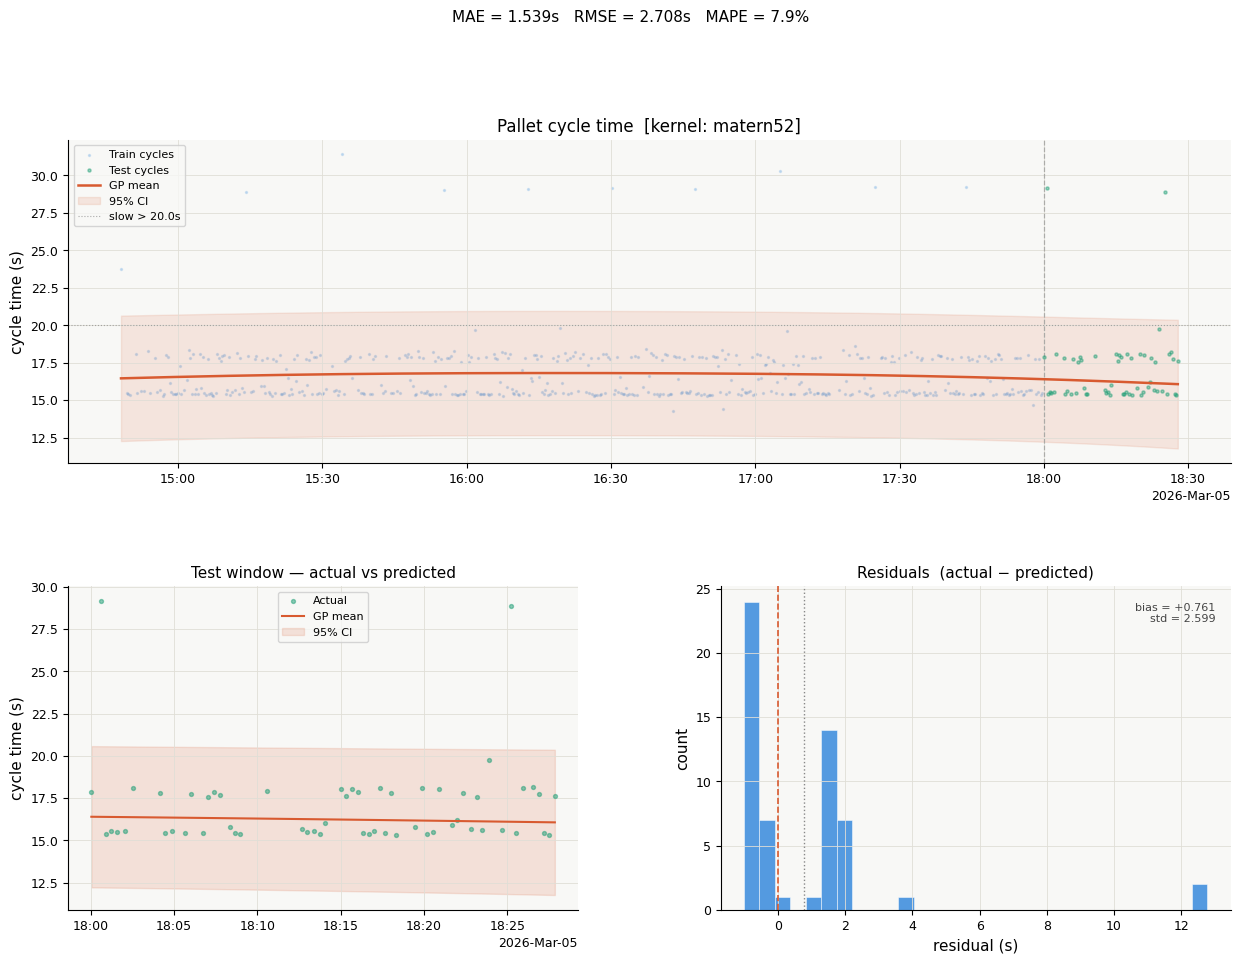


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  cycle_time_s  [matern52]
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Kernel   : matern52
  Lengthscale = 6.4h. Cycles within ~6.4h of each other are treated as correlated.
  Noise    : HIGH (2.113s, 100% of signal std). Very noisy or kernel mismatch.
  Accuracy : Good — MAPE 7.9%, MAE = 1.539s
  MAE = 1.539s   RMSE = 2.708s   MAPE = 7.95%

  CI note  : CI width reflects data density — sparse periods
             (e.g. shift breaks) get wider bands automatically.

  ⚠  High noise — expected for raw per-cycle data.
     The GP is modelling the mean trend through the noise.
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


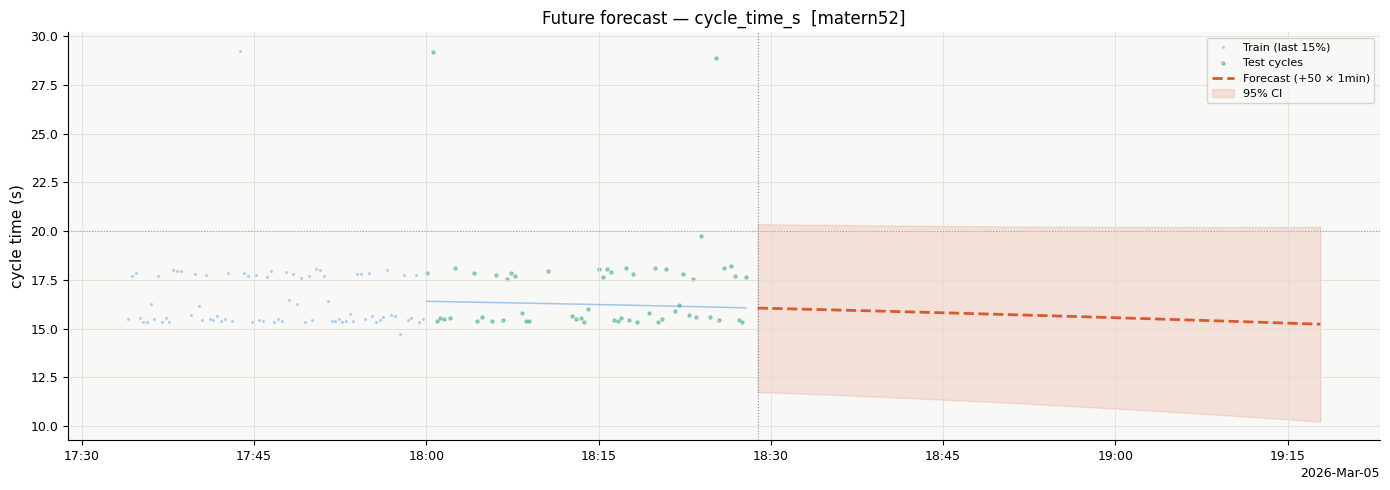


First 5 steps:
  2026-03-05 18:28:50.962000  →  16.051s  (95% CI: 11.744 – 20.358)
  2026-03-05 18:29:50.962000  →  16.037s  (95% CI: 11.723 – 20.351)
  2026-03-05 18:30:50.961999999  →  16.023s  (95% CI: 11.701 – 20.345)
  2026-03-05 18:31:50.961999999  →  16.009s  (95% CI: 11.679 – 20.339)
  2026-03-05 18:32:50.962000  →  15.994s  (95% CI: 11.656 – 20.332)


In [14]:
# ── PARAMETERS ─────────────────────────────────────────────────────
TRAIN_START = "2026-03-05 14:00"
TRAIN_END   = "2026-03-05 18:00"
TEST_END    = "2026-03-05 18:30"
KERNEL      = "matern52"   # "rbf" | "matern52" | "matern32" | "periodic+rbf"
N_RESTARTS  = 3

# Future extrapolation beyond TEST_END
N_FUTURE        = 50   # steps ahead  (0 = skip)
FUTURE_STEP_MIN = 1    # step resolution in minutes
# ───────────────────────────────────────────────────────────────────

r = run_gp(
    train_start=TRAIN_START, train_end=TRAIN_END, test_end=TEST_END,
    kernel=KERNEL, n_restarts=N_RESTARTS, verbose=True,
)

show_results(r)

# ── Optional future extrapolation ───────────────────────────────────
if N_FUTURE > 0:
    t0       = r["t0"]
    t_scale  = r["t_scale"]
    t_test   = r["t_test"].ravel()
    model    = r["model"]

    step_norm = (FUTURE_STEP_MIN * 60) / t_scale
    t_future  = (
        t_test.max() + np.arange(1, N_FUTURE + 1) * step_norm
    ).reshape(-1, 1)
    mu_fut, var_fut = model.predict(t_future)
    mu_fut  = mu_fut.ravel()
    std_fut = np.sqrt(np.clip(var_fut.ravel(), 0, None))
    dt_future = _to_dt(t0, t_future.ravel(), t_scale)

    t_train  = r["t_train"].ravel()
    y_train  = r["y_train"]
    lookback = max(1, int(len(t_train) * 0.15))
    dt_ctx   = _to_dt(t0, t_train[-lookback:], t_scale)

    t_grid = np.linspace(t_test.min(), t_test.max(), 200).reshape(-1, 1)
    mu_grid, _ = model.predict(t_grid)
    dt_grid = _to_dt(t0, t_grid.ravel(), t_scale)

    fig, ax = plt.subplots(figsize=(14, 5))
    ax.scatter(dt_ctx, y_train[-lookback:],
               s=2, alpha=0.25, color="#378ADD", label="Train (last 15%)")
    ax.scatter(_to_dt(t0, r["t_test"].ravel(), t_scale), r["y_test"],
               s=5, alpha=0.4, color="#1D9E75", label="Test cycles")
    ax.plot(dt_grid, mu_grid.ravel(), color="#378ADD", lw=1.1, alpha=0.45)
    ax.plot(dt_future, mu_fut, "--", color="#D85A30", lw=2,
            label=f"Forecast (+{N_FUTURE} × {FUTURE_STEP_MIN}min)")
    ax.fill_between(
        dt_future,
        mu_fut - 1.96 * std_fut,
        mu_fut + 1.96 * std_fut,
        color="#D85A30", alpha=0.15, label="95% CI",
    )
    ax.axhline(SLOW_THRESHOLD, color="#888", lw=0.8, linestyle=":", alpha=0.7)
    ax.axvline(dt_future[0], color="#888", lw=0.8, linestyle=":")
    ax.set_title(f"Future forecast — cycle_time_s  [{KERNEL}]", fontsize=12)
    ax.set_ylabel("cycle time (s)")
    ax.legend(fontsize=8)
    _fmt_xaxis(ax)
    plt.tight_layout()
    plt.show()

    print(f"\nFirst {min(5, N_FUTURE)} steps:")
    for dt, mu, sd in zip(dt_future[:5], mu_fut[:5], std_fut[:5]):
        print(f"  {dt}  →  {mu:.3f}s  "
              f"(95% CI: {mu - 1.96*sd:.3f} – {mu + 1.96*sd:.3f})")

## 5b — GP Anomaly Detection

Flags cycles whose duration falls outside the GP's predictive interval.
The CI adapts to local data density — gaps (shift breaks, stoppages) automatically
get wider bands, reducing false positives.

reconstraining parameters sparse_gp.Mat52.lengthscale



  cycle_time_s  [matern52]
  Train : 2026-03-05 08:00:06.933000
        → 2026-03-05 15:59:48.216000  (929 cycles)
  Test  : 2026-03-05 16:00:09.492000
        → 2026-03-05 17:59:40.905000  (331 cycles)
  Inducing pts : 92
  t_scale      : 28781s  (479.7min)
Optimising...
  MAE  = 5.355 s
  RMSE = 6.565 s
  MAPE = 31.45%


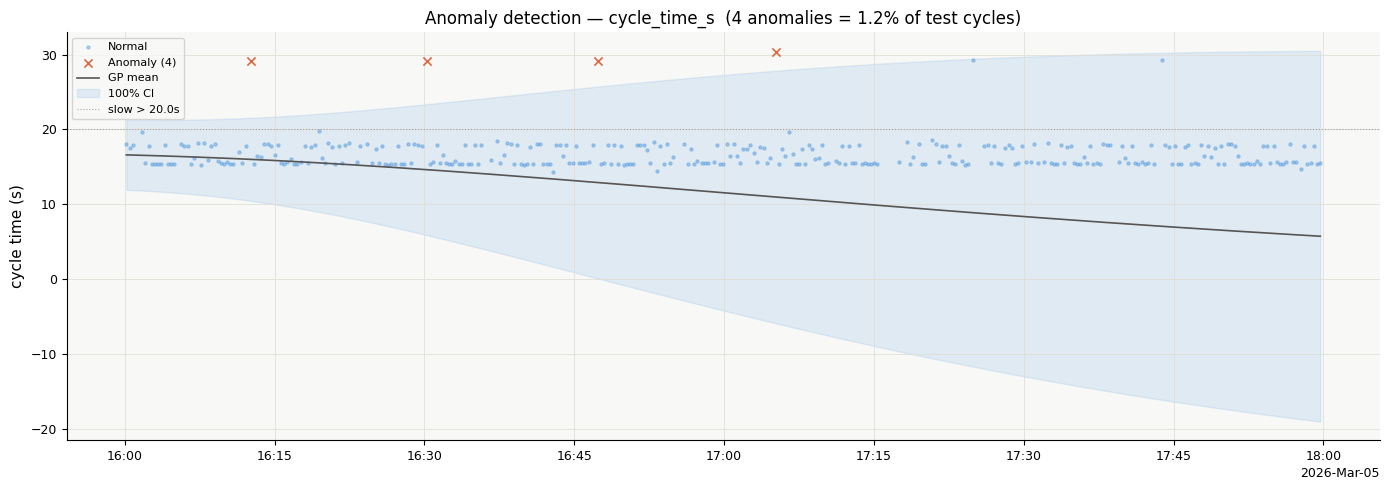


Anomaly report — cycle_time_s
  Test cycles  : 331
  Anomalies    : 4  (1.2%)
  CI level     : ±1.96σ

  Anomalous cycles:
    2026-03-05 16:12:39.349999999  actual = 29.125s  expected = 15.993s  CI = [10.444, 21.542]  → SLOW
    2026-03-05 16:30:14.522000  actual = 29.187s  expected = 14.618s  CI = [5.872, 23.365]  → SLOW
    2026-03-05 16:47:23.125000  actual = 29.094s  expected = 12.898s  CI = [0.074, 25.721]  → SLOW
    2026-03-05 17:05:09.172000  actual = 30.282s  expected = 10.965s  CI = [-5.903, 27.833]  → SLOW


In [15]:
# ── PARAMETERS ─────────────────────────────────────────────────────
TRAIN_START = "2026-03-05 08:00"
TRAIN_END   = "2026-03-05 16:00"
TEST_END    = "2026-03-05 18:00"
KERNEL      = "matern52"
CI_LEVEL    = 1.96   # 1.96 = 95%  |  2.58 = 99%
# ───────────────────────────────────────────────────────────────────

r = run_gp(
    train_start=TRAIN_START, train_end=TRAIN_END, test_end=TEST_END,
    kernel=KERNEL, verbose=True,
)

t0        = r["t0"]
t_scale   = r["t_scale"]
mean_pred = r["forecast_mean"]
std_pred  = np.sqrt(np.clip(r["forecast_var"], 0, None))
y_test    = r["y_test"]
dt_test   = _to_dt(t0, r["t_test"].ravel(), t_scale)

lo = mean_pred - CI_LEVEL * std_pred
hi = mean_pred + CI_LEVEL * std_pred
anomaly_mask = (y_test < lo) | (y_test > hi)
n_anom = anomaly_mask.sum()

# ── Plot ────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 5))

ax.scatter(
    [d for d, a in zip(dt_test, anomaly_mask) if not a],
    y_test[~anomaly_mask],
    s=5, alpha=0.35, color="#378ADD", label="Normal", zorder=2,
)
ax.scatter(
    [d for d, a in zip(dt_test, anomaly_mask) if a],
    y_test[anomaly_mask],
    s=35, alpha=0.9, color="#D85A30", marker="x",
    linewidths=1.2, label=f"Anomaly ({n_anom})", zorder=4,
)
ax.plot(dt_test, mean_pred, color="#555", lw=1.2, label="GP mean", zorder=3)
ax.fill_between(dt_test, lo, hi,
                color="#378ADD", alpha=0.12, label=f"{CI_LEVEL*100/1.96:.0f}% CI")
ax.axhline(SLOW_THRESHOLD, color="#888", lw=0.8,
           linestyle=":", alpha=0.7, label=f"slow > {SLOW_THRESHOLD}s")

ax.set_title(
    f"Anomaly detection — cycle_time_s  "
    f"({n_anom} anomalies = {n_anom / len(y_test) * 100:.1f}% of test cycles)",
    fontsize=12,
)
ax.set_ylabel("cycle time (s)")
ax.legend(fontsize=8)
_fmt_xaxis(ax)
plt.tight_layout()
plt.show()

# ── Report ──────────────────────────────────────────────────────────
print(f"\nAnomaly report — cycle_time_s")
print(f"  Test cycles  : {len(y_test):,}")
print(f"  Anomalies    : {n_anom}  ({n_anom / len(y_test) * 100:.1f}%)")
print(f"  CI level     : ±{CI_LEVEL}σ")

if n_anom > 0:
    print(f"\n  Anomalous cycles:")
    for idx in np.where(anomaly_mask)[0]:
        tag = "SLOW" if y_test[idx] > hi[idx] else "FAST"
        print(f"    {dt_test[idx]}  "
              f"actual = {y_test[idx]:.3f}s  "
              f"expected = {mean_pred[idx]:.3f}s  "
              f"CI = [{lo[idx]:.3f}, {hi[idx]:.3f}]  → {tag}")
else:
    print("\n  ✓  No anomalies detected in test window.")